# 01 — Pair Correlations & Power-Law Fits

Analyse the equal-time pair correlator $P(r)$ for the 1D attractive Hubbard model.

**Research question**: Does $P(r)$ decay as a power law $\sim r^{-\eta_P}$ (Luther-Emery liquid)
or exponentially (gapped)? For $U < 0$ and $n_\sigma = 0.4$ we expect power-law in the NN case;
long-range hopping should reduce $\eta_P$.

**Sections**
1. NN hopping at $n_\sigma = 0.4$ — confirm power-law, extract $\eta_P$
2. LR hopping at $n_\sigma = 0.4$ — vary $\alpha$, measure change in $\eta_P$
3. Power-law exponent summary — compare to Luther-Emery prediction

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import sys, os

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
from analysis import SimParams, extract_equal_time, DATA_DIR, RESULTS_DIR  # type: ignore

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'figure.dpi': 150,
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'legend.framealpha': 0.92,
    'legend.edgecolor': '0.75',
    'lines.linewidth': 1.8,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
})


def power_law_fit(r, vals, r_min=3, r_max=None):
    """Fit vals(r) = A * r^{-eta} via log-log linear regression."""
    if r_max is None:
        r_max = r.max()
    mask = (r >= r_min) & (r <= r_max) & (vals > 0)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    slope, intercept, rval, _, _ = linregress(np.log(r[mask]), np.log(vals[mask]))
    return -slope, np.exp(intercept), rval**2   # eta, A, R²


def exp_fit(r, vals, r_min=3, r_max=None):
    """Fit |vals(r)| = A * exp(-r/xi) via log-linear regression."""
    if r_max is None:
        r_max = r.max()
    mask = (r >= r_min) & (r <= r_max) & (vals > 0)
    if mask.sum() < 2:
        return np.nan, np.nan, np.nan
    slope, intercept, rval, _, _ = linregress(r[mask], np.log(vals[mask]))
    xi = -1.0 / slope
    return xi, np.exp(intercept), rval**2       # xi, A, R²


def nice_round(x):
    """Round x to the nearest publication-friendly number (0.25 increments up to 4)."""
    options = [0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
    return min(options, key=lambda v: abs(v - x))


def fmt_nice(x):
    """Format a nice number without trailing zeros (e.g. 1.0 -> '1', 0.5 -> '0.5')."""
    if x == int(x):
        return str(int(x))
    return f'{x:g}'

## Section 1: NN hopping, $n_\sigma = 0.4$

Update `mu_star` after running the density calibration in `00_sanity.ipynb`.

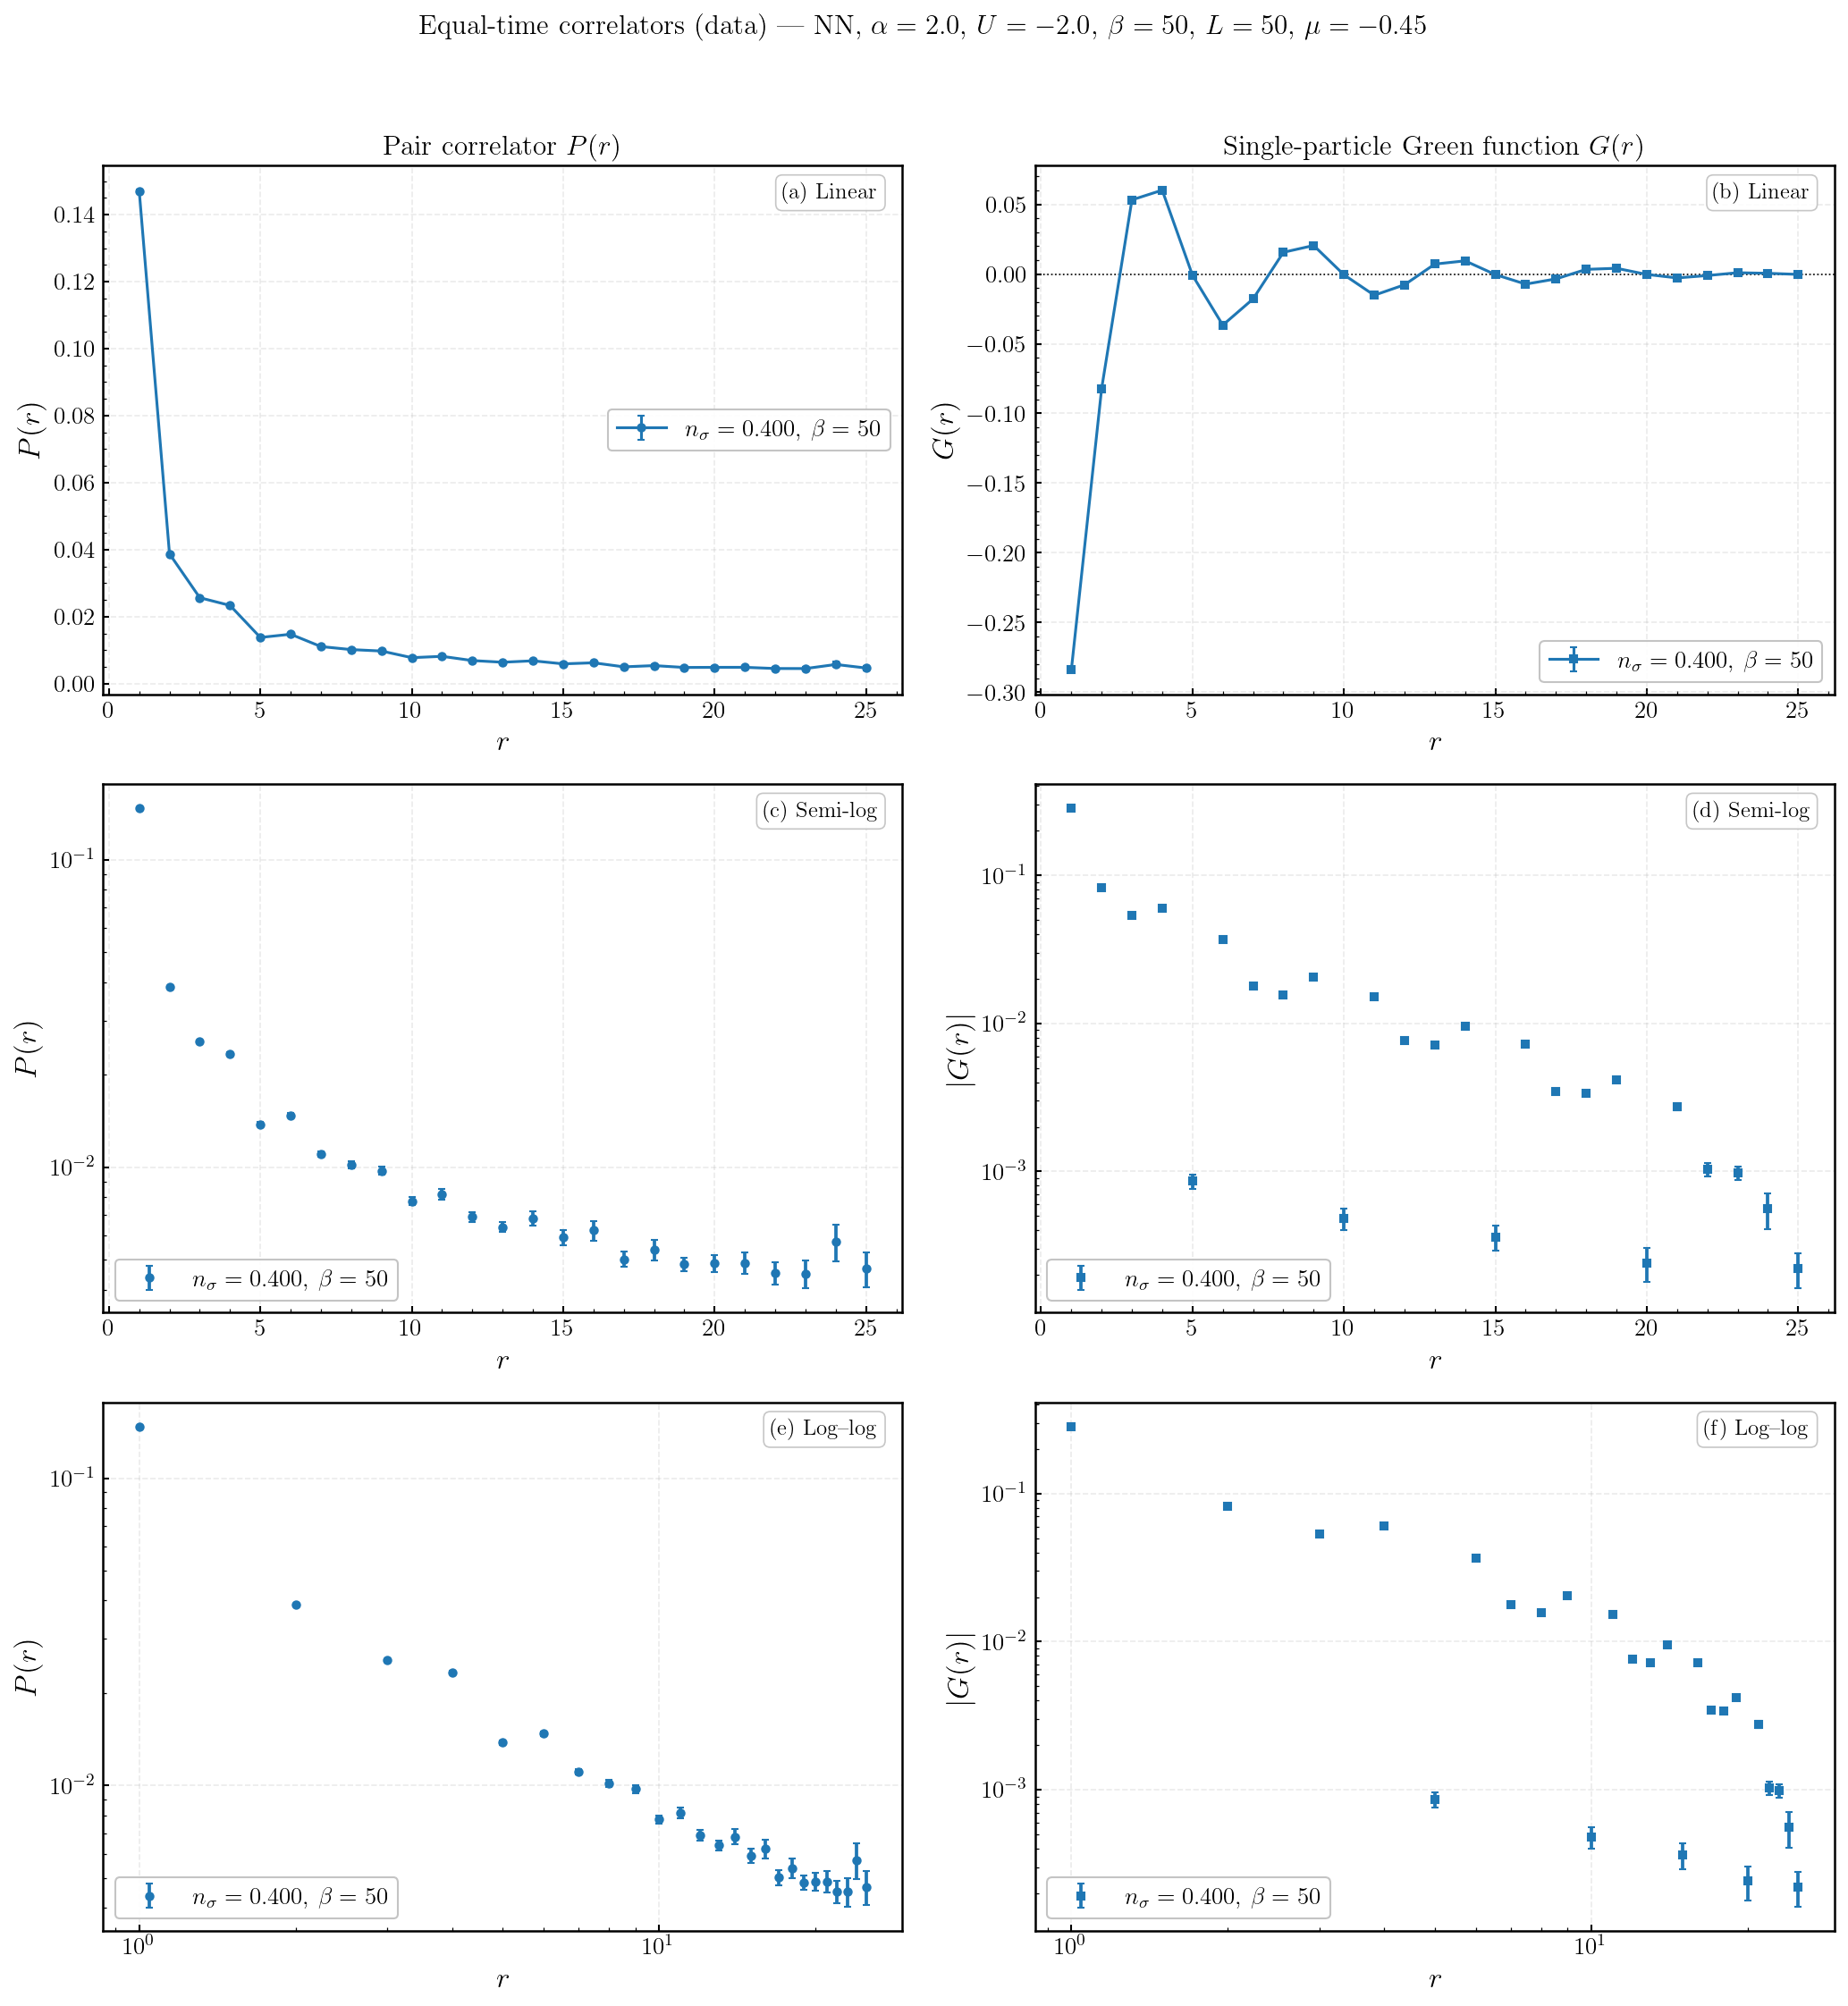

In [2]:
# ── Parameters ────────────────────────────────────────────────────────────────
U = -2.0
L = 50
r_fold    = L // 2
r_min_fit = 1

nn_runs = [
    SimParams(U=U, mu=-0.45, beta=50.0, L=50, alpha=2.0, Rmax=1),
]

# ── Figure setup ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

axes[0, 0].set_title(r'Pair correlator $P(r)$')
axes[0, 1].set_title(r'Single-particle Green function $G(r)$')

for i, (yl, yr) in enumerate(zip(
        [r'$P(r)$', r'$P(r)$', r'$P(r)$'],
        [r'$G(r)$', r'$|G(r)|$', r'$|G(r)|$'])):
    axes[i, 0].set_ylabel(yl)
    axes[i, 1].set_ylabel(yr)

panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
row_tags     = ['Linear', 'Semi-log', 'Log--log']
for n_ax, (ax, letter) in enumerate(zip(axes.flat, panel_labels)):
    ax.text(0.97, 0.97, fr'{letter} {row_tags[n_ax // 2]}',
            transform=ax.transAxes, fontsize=12, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.88, ec='0.75', lw=0.8))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# ── Data (no fits) ────────────────────────────────────────────────────────────
for idx, params in enumerate(nn_runs):
    color = colors[idx % len(colors)]
    try:
        d_P = extract_equal_time(params, 'pair',   'position', base=DATA_DIR)
        d_G = extract_equal_time(params, 'greens', 'position', base=DATA_DIR)
    except FileNotFoundError as e:
        print(f'[skip] mu={params.mu}: {e}')
        continue

    r_p, P, P_err = d_P['r'], d_P['values'], d_P['errors']
    r_g, G, G_err = d_G['r'], d_G['values'], d_G['errors']
    mask_p = (r_p >= 1) & (r_p <= r_fold)
    mask_g = (r_g >= 1) & (r_g <= r_fold)
    r_p, P,   P_err = r_p[mask_p], P[mask_p],  P_err[mask_p]
    r_g, G,   G_err = r_g[mask_g], G[mask_g],  G_err[mask_g]
    absG, absG_err  = np.abs(G), np.abs(G_err)

    snr_P = P    > P_err
    snr_G = absG > absG_err

    n_meas = d_P['density']
    lbl = fr'$n_\sigma={n_meas/2:.3f}$, $\beta={params.beta:.0f}$'

    # Row 0: linear
    axes[0, 0].errorbar(r_p, P, yerr=P_err,
                        fmt='o-', ms=4, capsize=2, lw=1.5, color=color, label=lbl)
    axes[0, 1].errorbar(r_g, G, yerr=G_err,
                        fmt='s-', ms=4, capsize=2, lw=1.5, color=color, label=lbl)
    axes[0, 1].axhline(0, color='k', lw=0.8, ls=':')

    # Row 1: semi-log (SNR > 1)
    axes[1, 0].errorbar(r_p[snr_P], P[snr_P], yerr=P_err[snr_P],
                        fmt='o', ms=4, capsize=2, color=color, label=lbl)
    axes[1, 1].errorbar(r_g[snr_G], absG[snr_G], yerr=absG_err[snr_G],
                        fmt='s', ms=4, capsize=2, color=color, label=lbl)

    # Row 2: log-log (clip lower error bar)
    r_snr, P_snr, err_snr = r_p[snr_P], P[snr_P], P_err[snr_P]
    err_lo = np.minimum(err_snr, P_snr * 0.9999)
    axes[2, 0].errorbar(r_snr, P_snr, yerr=np.vstack([err_lo, err_snr]),
                        fmt='o', ms=4, capsize=2, color=color, label=lbl)

    r_snrG, absG_snr, errG_snr = r_g[snr_G], absG[snr_G], absG_err[snr_G]
    errG_lo = np.minimum(errG_snr, absG_snr * 0.9999)
    axes[2, 1].errorbar(r_snrG, absG_snr, yerr=np.vstack([errG_lo, errG_snr]),
                        fmt='s', ms=4, capsize=2, color=color, label=lbl)

# ── Axis scales ───────────────────────────────────────────────────────────────
for ax in axes[1, :]:
    ax.set_yscale('log')
for ax in axes[2, :]:
    ax.set_xscale('log')
    ax.set_yscale('log')

for ax in axes.flat:
    ax.set_xlabel(r'$r$')
    ax.legend(fontsize=13)

# ── Figure title and save ─────────────────────────────────────────────────────
p0         = nn_runs[0]
mus        = [p.mu   for p in nn_runs]
betas      = [p.beta for p in nn_runs]
mu_sweep   = len(set(mus))   > 1
beta_sweep = len(set(betas)) > 1

mu_str   = r'$\mu$ sweep'   if mu_sweep   else fr'$\mu={p0.mu:.2f}$'
beta_str = r'$\beta$ sweep' if beta_sweep else fr'$\beta={p0.beta:.0f}$'
hop_str  = r'NN'            if p0.Rmax == 1 else fr'LR ($R_{{\rm max}}={p0.Rmax}$)'

title = (fr'Equal-time correlators (data) --- {hop_str}, '
         fr'$\alpha={p0.alpha}$,  $U={p0.U}$,  {beta_str},  $L={p0.L}$,  {mu_str}')
fig.suptitle(title, y=0.998, fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.98])

hop_tag   = 'NN' if p0.Rmax == 1 else f'LR_Rmax{p0.Rmax}'
alpha_tag = '' if p0.Rmax == 1 else f'_a{p0.alpha}'
mu_tag    = '_musweep' if mu_sweep else f'_mu{p0.mu}'
beta_tag  = 'bsweep' if beta_sweep else f'b{p0.beta:.0f}'
fname     = f'correlators_{hop_tag}{alpha_tag}_U{p0.U}{mu_tag}_{beta_tag}_L{p0.L}_data.pdf'
plt.savefig(RESULTS_DIR / fname, bbox_inches='tight')
plt.show()

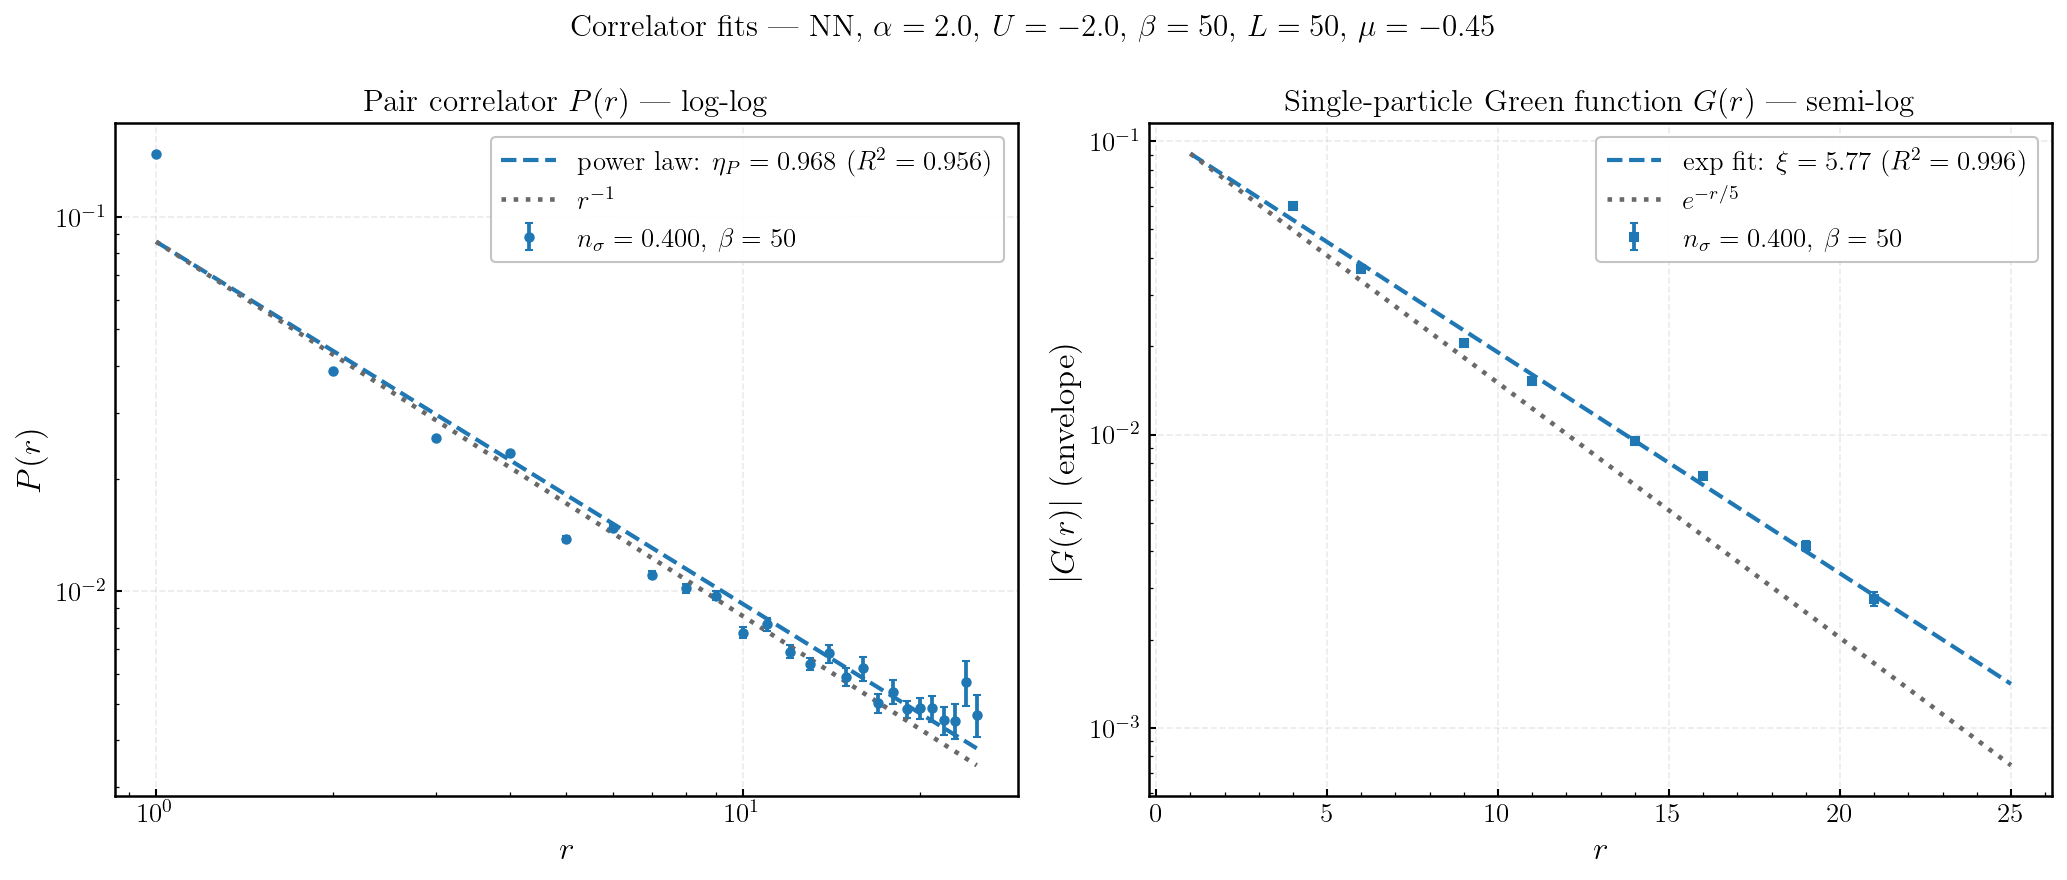

NN exponents: {-0.45: 0.9676373294678292}


In [3]:
from scipy.signal import argrelmax

# ── Fits + rounded analytical overlays (2 panels) ────────────────────────────
# Uses nn_runs, r_fold, r_min_fit defined in the data cell above.
# G(r): fit the *envelope* (local maxima of |G|) to avoid oscillation-node artifacts.

fig, (ax_P, ax_G) = plt.subplots(1, 2, figsize=(14, 6))

ax_P.set_xlabel(r'$r$')
ax_P.set_ylabel(r'$P(r)$')
ax_P.set_title(r'Pair correlator $P(r)$ --- log-log')
ax_P.set_xscale('log')
ax_P.set_yscale('log')

ax_G.set_xlabel(r'$r$')
ax_G.set_ylabel(r'$|G(r)|$ (envelope)')
ax_G.set_title(r'Single-particle Green function $G(r)$ --- semi-log')
ax_G.set_yscale('log')

eta_nn = {}
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for idx, params in enumerate(nn_runs):
    color = colors[idx % len(colors)]
    try:
        d_P = extract_equal_time(params, 'pair',   'position', base=DATA_DIR)
        d_G = extract_equal_time(params, 'greens', 'position', base=DATA_DIR)
    except FileNotFoundError as e:
        print(f'[skip] mu={params.mu}: {e}')
        continue

    # ── Pair correlator ───────────────────────────────────────────────────────
    r_p, P, P_err = d_P['r'], d_P['values'], d_P['errors']
    mask_p = (r_p >= 1) & (r_p <= r_fold)
    r_p, P, P_err = r_p[mask_p], P[mask_p], P_err[mask_p]
    snr_P = P > P_err

    # ── Green function envelope ───────────────────────────────────────────────
    r_g, G, G_err = d_G['r'], d_G['values'], d_G['errors']
    mask_g = (r_g >= 1) & (r_g <= r_fold)
    r_g, G, G_err = r_g[mask_g], G[mask_g], G_err[mask_g]
    absG, absG_err = np.abs(G), np.abs(G_err)

    # order=1: each point only needs to beat its immediate neighbors.
    # This captures all oscillation peaks even when the envelope is small.
    # SNR filter is applied separately for plotting only; exp_fit uses all peaks.
    peak_idx = argrelmax(absG, order=1)[0]
    env_mask = np.zeros(len(absG), dtype=bool)
    env_mask[peak_idx] = True

    r_env     = r_g[env_mask]
    G_env     = absG[env_mask]
    G_env_err = absG_err[env_mask]

    n_meas = d_P['density']
    lbl = fr'$n_\sigma={n_meas/2:.3f}$, $\beta={params.beta:.0f}$'

    # ── Fits ──────────────────────────────────────────────────────────────────
    eta_P, A_P, r2_P = power_law_fit(r_p,  P,     r_min=r_min_fit, r_max=r_fold)
    xi_G,  B_G, s2_G = exp_fit(r_env, G_env, r_min=r_min_fit, r_max=r_fold)
    eta_nn[params.mu] = eta_P

    r_log = np.geomspace(max(r_min_fit, 1), r_fold, 400)
    r_lin = np.linspace(r_min_fit, r_fold, 400)

    # ── Log-log P(r) ──────────────────────────────────────────────────────────
    r_snr, P_snr, err_snr = r_p[snr_P], P[snr_P], P_err[snr_P]
    err_lo = np.minimum(err_snr, P_snr * 0.9999)
    ax_P.errorbar(r_snr, P_snr, yerr=np.vstack([err_lo, err_snr]),
                  fmt='o', ms=4, capsize=2, color=color, label=lbl)
    if not np.isnan(eta_P):
        eta_r   = nice_round(eta_P)
        eta_lbl = fmt_nice(eta_r)
        r_ref   = r_log[0]
        C_eta   = A_P * r_ref**(-eta_P) / r_ref**(-eta_r)
        ax_P.plot(r_log, A_P * r_log**(-eta_P), '--', lw=2.0,
                  color=color,
                  label=fr'power law: $\eta_P={eta_P:.3f}$  ($R^2={r2_P:.3f}$)')
        ax_P.plot(r_log, C_eta * r_log**(-eta_r), ':', lw=2.2,
                  color='dimgray',
                  label=fr'$r^{{-{eta_lbl}}}$')

    # ── Semi-log |G(r)| envelope ──────────────────────────────────────────────
    env_lo = np.minimum(G_env_err, G_env * 0.9999)
    ax_G.errorbar(r_env, G_env, yerr=np.vstack([env_lo, G_env_err]),
                  fmt='s', ms=4, capsize=2, color=color, label=lbl)
    if not np.isnan(xi_G):
        xi_r   = nice_round(xi_G)
        xi_lbl = fmt_nice(xi_r)
        r_ref  = r_lin[0]
        C_xi   = B_G * np.exp(-r_ref / xi_G) / np.exp(-r_ref / xi_r)
        ax_G.plot(r_lin, B_G * np.exp(-r_lin / xi_G), '--', lw=2.0,
                  color=color,
                  label=fr'exp fit: $\xi={xi_G:.2f}$  ($R^2={s2_G:.3f}$)')
        ax_G.plot(r_lin, C_xi * np.exp(-r_lin / xi_r), ':', lw=2.2,
                  color='dimgray',
                  label=fr'$e^{{-r/{xi_lbl}}}$')

ax_P.legend(fontsize=13)
ax_G.legend(fontsize=13)

# ── Figure title and save ─────────────────────────────────────────────────────
p0         = nn_runs[0]
mus        = [p.mu   for p in nn_runs]
betas      = [p.beta for p in nn_runs]
mu_sweep   = len(set(mus))   > 1
beta_sweep = len(set(betas)) > 1

mu_str   = r'$\mu$ sweep'   if mu_sweep   else fr'$\mu={p0.mu:.2f}$'
beta_str = r'$\beta$ sweep' if beta_sweep else fr'$\beta={p0.beta:.0f}$'
hop_str  = r'NN'            if p0.Rmax == 1 else fr'LR ($R_{{\rm max}}={p0.Rmax}$)'

title = (fr'Correlator fits --- {hop_str}, '
         fr'$\alpha={p0.alpha}$,  $U={p0.U}$,  {beta_str},  $L={p0.L}$,  {mu_str}')
fig.suptitle(title, fontsize=15)
plt.tight_layout()

hop_tag   = 'NN' if p0.Rmax == 1 else f'LR_Rmax{p0.Rmax}'
alpha_tag = '' if p0.Rmax == 1 else f'_a{p0.alpha}'
mu_tag    = '_musweep' if mu_sweep else f'_mu{p0.mu}'
beta_tag  = 'bsweep' if beta_sweep else f'b{p0.beta:.0f}'
fname     = f'correlators_{hop_tag}{alpha_tag}_U{p0.U}{mu_tag}_{beta_tag}_L{p0.L}_fits.pdf'
plt.savefig(RESULTS_DIR / fname, bbox_inches='tight')
plt.show()
print('NN exponents:', eta_nn)

### How to see trends

**What each panel tells you**

| Panel | What a straight line means |
|-------|---------------------------|
| $P(r)$ semi-log | exponential decay (gapped) |
| $P(r)$ log-log | power-law decay (Luther-Emery liquid) ✓ expected |
| $G(r)$ linear | 2 $k_F$ Friedel oscillations — period $\approx 1/n_\sigma$ sites |
| $G(r)$ semi-log | exponential envelope $\sim e^{-r/\xi}$ ✓ expected |
| $G(r)$ log-log | curvature = not a power law (confirms exponential) |

**Three ways to generate a visible trend (without new simulations)**

1. **β sweep** — uncomment the other `SimParams` lines in `nn_runs`. Each β overlays as a separate color.
   - On the semi-log $G$ panel: watch $\xi(\beta)$ grow as $\beta$ increases. If it diverges → gapless; if it saturates → gapped.
   - On the log-log $P$ panel: watch $\eta_P(\beta)$ converge to its ground-state value.

2. **Right density** — `mu_star = -1.0` gives $n = 0.76$, not the target $n_\sigma = 0.4$. At the wrong filling the correlators are much shorter-ranged. Update `mu_star` from `00_sanity.ipynb` first.

3. **Fit-range sensitivity** — vary `r_min` in `power_law_fit` / `exp_fit` (e.g. 3, 5, 10). If $\eta_P$ and $\xi$ are stable across choices, the fit is trustworthy; if they shift a lot, the signal is too noisy or the range too short.

## Section 2: LR hopping, $n_\sigma = 0.4$

Update `mu_lr_star` after running the LR density calibration.

[skip] α=0.5: Simulation directory not found. Tried:
  /Users/georgeissa/Documents/Batrouni/lr-Hub/data/hubbard_U-3.00_mu-2.40_b60.00_L50_a0.50_Rmax50-1
  /Users/georgeissa/Documents/Batrouni/lr-Hub/data/hubbard_chain_LR_U-3.00_m-2.40_b60.00_L50_a0.50_Rmax50-1
  /Users/georgeissa/Documents/Batrouni/lr-Hub/data/hubbard_chain_U-3.00_m-2.40_L50_b60.00-1
[skip] α=0.8: Simulation directory not found. Tried:
  /Users/georgeissa/Documents/Batrouni/lr-Hub/data/hubbard_U-3.00_mu-2.40_b60.00_L50_a0.80_Rmax50-1
  /Users/georgeissa/Documents/Batrouni/lr-Hub/data/hubbard_chain_LR_U-3.00_m-2.40_b60.00_L50_a0.80_Rmax50-1
  /Users/georgeissa/Documents/Batrouni/lr-Hub/data/hubbard_chain_U-3.00_m-2.40_L50_b60.00-1
[skip] α=1.0: Simulation directory not found. Tried:
  /Users/georgeissa/Documents/Batrouni/lr-Hub/data/hubbard_U-3.00_mu-2.40_b60.00_L50_a1.00_Rmax50-1
  /Users/georgeissa/Documents/Batrouni/lr-Hub/data/hubbard_chain_LR_U-3.00_m-2.40_b60.00_L50_a1.00_Rmax50-1
  /Users/georgeissa/Documents/Bat

/var/folders/vy/znqs4wgd6dgd_l_cpys7gjl40000gn/T/ipykernel_73965/1645708816.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


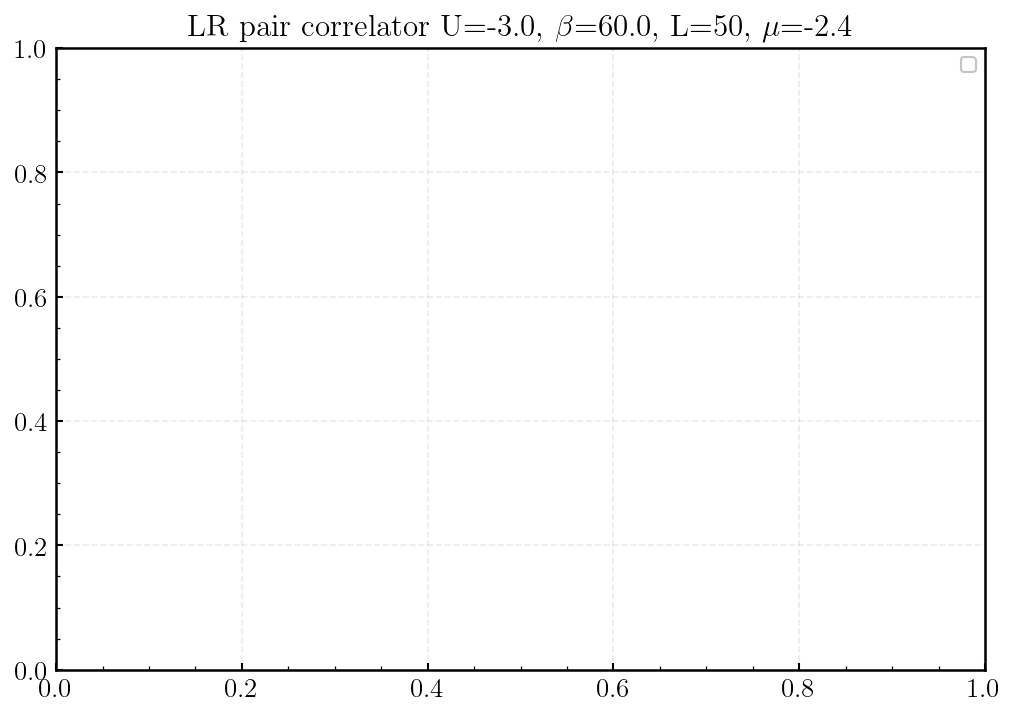

LR exponents: {}


In [50]:
mu_lr_star = -2.4   # <-- update after LR density calibration
beta_lr = 60.0
Rmax_lr = 50

lr_runs = [
    SimParams(U=U, mu=mu_lr_star, beta=beta_lr, L=L, alpha=0.5, Rmax=Rmax_lr),
    SimParams(U=U, mu=mu_lr_star, beta=beta_lr, L=L, alpha=0.8, Rmax=Rmax_lr),
    SimParams(U=U, mu=mu_lr_star, beta=beta_lr, L=L, alpha=1.0, Rmax=Rmax_lr),
    SimParams(U=U, mu=mu_lr_star, beta=beta_lr, L=L, alpha=1.5, Rmax=Rmax_lr),
    SimParams(U=U, mu=mu_lr_star, beta=beta_lr, L=L, alpha=2.0, Rmax=Rmax_lr),
]

fig, ax = plt.subplots(figsize=(7, 5))
eta_lr = {}

for params in lr_runs:
    try:
        data = extract_equal_time(params, 'pair', 'position', base=DATA_DIR)
    except FileNotFoundError as e:
        print(f"[skip] α={params.alpha}: {e}")
        continue

    r, P, err = data['r'], data['values'], data['errors']
    eta, A, r2 = power_law_fit(r, P)
    eta_lr[params.alpha] = eta
    lbl = fr'$\alpha$={params.alpha}  $\eta$={eta:.3f}'
    plot_pair_corr(ax, r, P, err, label=lbl)

    r_fit = np.linspace(5, r.max(), 200)
    ax.plot(r_fit, A * r_fit**(-eta), '--', lw=1)

ax.set_title(fr'LR pair correlator  U={U}, $\beta$={beta_lr}, L={L}, $\mu$={mu_lr_star}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'pair_corr_LR.pdf')
plt.show()
print('LR exponents:', eta_lr)

## Section 3: Power-law exponent summary

Luther-Emery prediction: $\eta_P = 1 / (2 K_\rho)$ where $K_\rho > 1$ for attraction.
LR hopping is expected to enhance pairing → reduce $\eta_P$.

In [51]:
if eta_lr:
    alphas_sorted = sorted(eta_lr.keys())
    etas_sorted   = [eta_lr[a] for a in alphas_sorted]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(alphas_sorted, etas_sorted, 'o-', label='DQMC')

    if eta_nn:
        eta_nn_mean = np.mean(list(eta_nn.values()))
        ax.axhline(eta_nn_mean, color='gray', ls='--', label=fr'NN avg $\eta$={eta_nn_mean:.3f}')

    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(r'$\eta_P$')
    ax.set_title(r'Pair correlator exponent vs $\alpha$')
    ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'eta_vs_alpha.pdf')
    plt.show()
else:
    print('No LR data loaded yet.')

No LR data loaded yet.
